Heatmap of SHX experiment

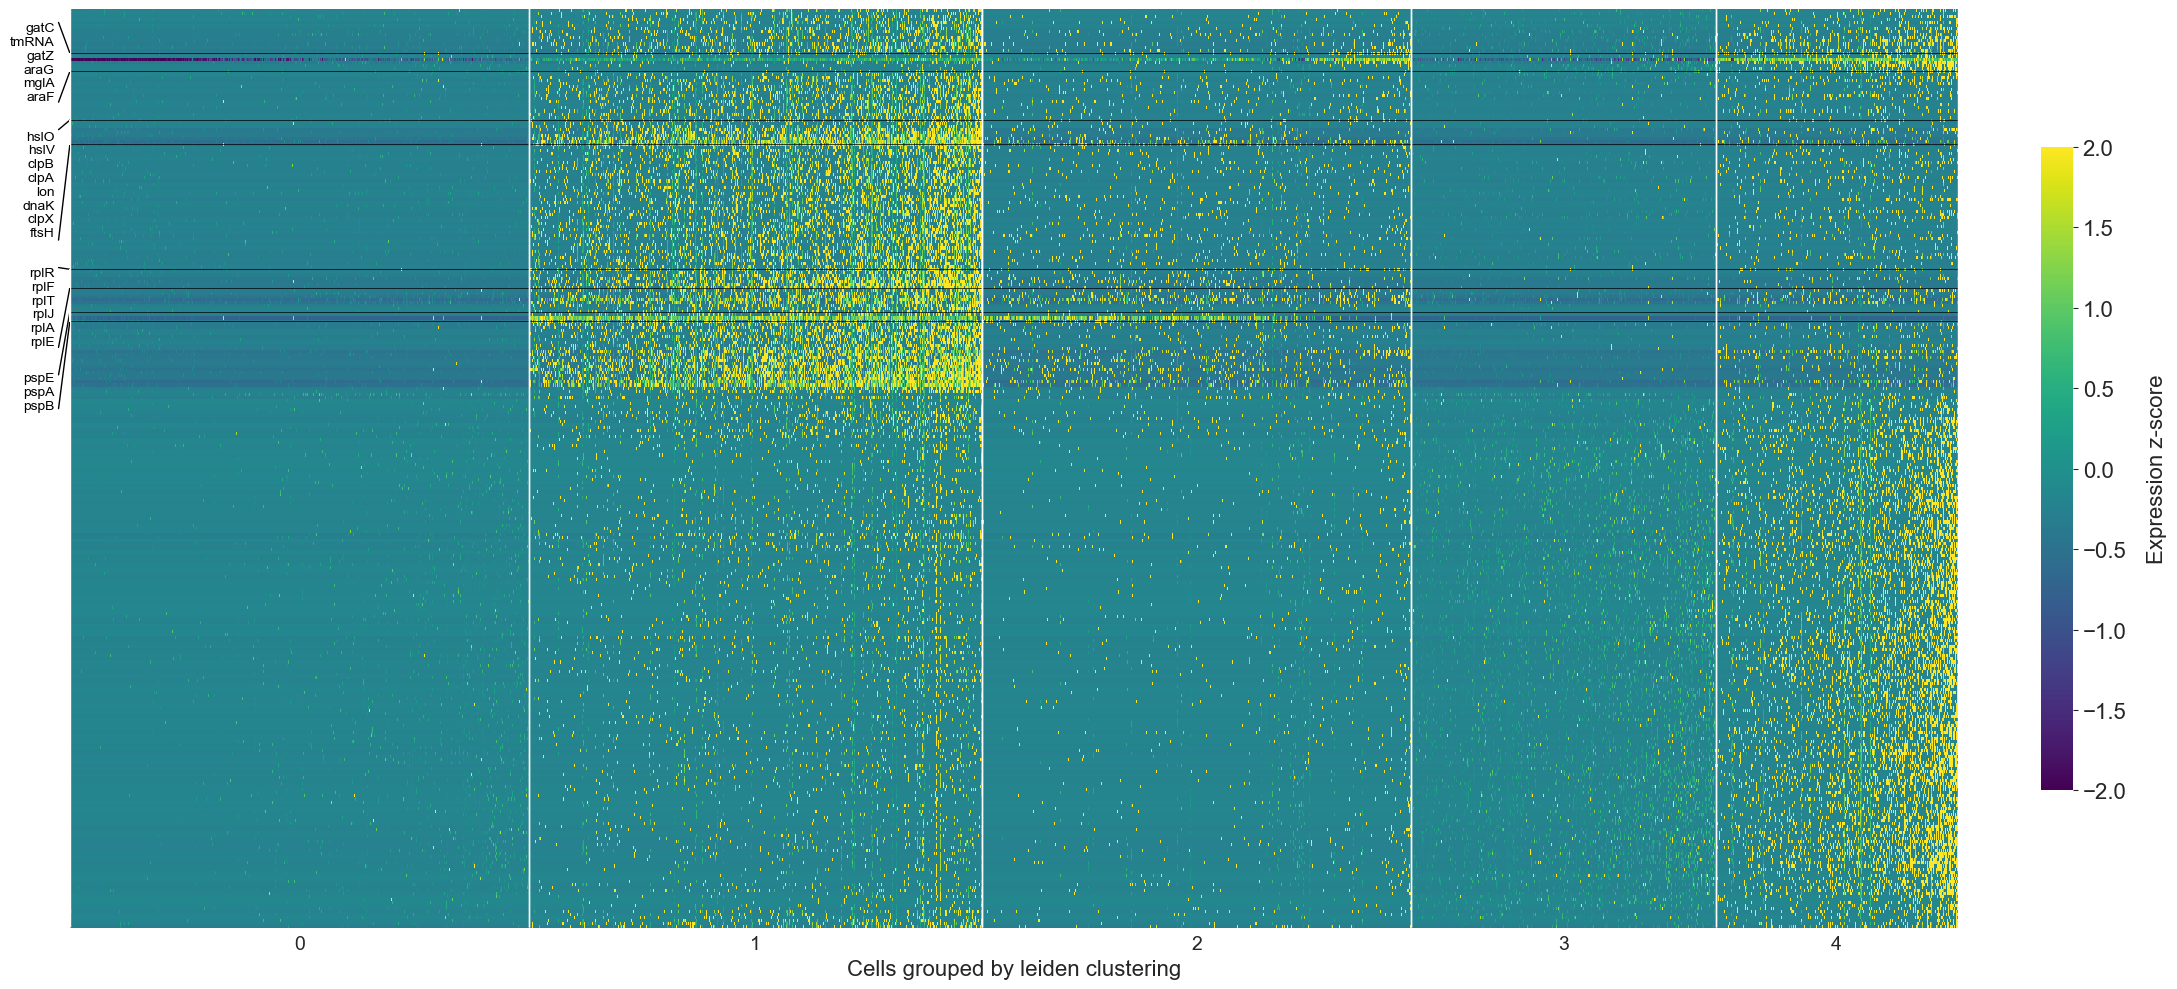

In [9]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
import scipy.sparse as sp
import os

# ---------------- CONFIG ----------------
groupby   = "leiden"
topN      = 100
p_cut     = 0.05
down_grp  = "0"            # for this cluster take the 100 lowest scores
use_raw   = False          # True -> use adata.raw
layer     = 'counts'           # e.g. "lognorm"
metric    = "correlation"
method    = "average"

# order cells inside each cluster: "umap" (fast) or "cluster" (hierarchical)
order_cells_within_cluster = "umap"
adata = sc.read_h5ad(os.path.join(os.path.dirname(os.getcwd()), 'data', 'scanpy_shx_scaled_by_total_rna.h5ad'))
# Curated groups to emphasize (edit to your genes)
gene_groups = {
    "Phage shock": ["pspA","pspB","pspC","pspD","pspE","pspF","pspG"],
    "Protease/Chaperones": ["clpA","clpB","clpX","clpP","lon","ftsH","dnaK","hslO","hslU","hslV"],
    "Ribosomal": ["rplA","rplB","rplC","rplD","rplE","rplF","rplJ","rplK","rplL","rplM","rplN","rplO","rplP","rplQ","rplR","rplS","rplT","rplU","rplV"],
    "Carbohydrate utilization": ['tmRNA',"gatA","gatB","gatC","gatZ", "mglA", "araG","araF"],
}
# ---------------------------------------

# ---------- 1) Rank & select markers (same rules as before) ----------
if "rank_genes_groups" not in adata.uns:
    sc.tl.rank_genes_groups(adata, groupby=groupby, method="wilcoxon", layer=layer, use_raw=use_raw)

df = sc.get.rank_genes_groups_df(adata, None).copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["pvals_adj","scores"])
cats = ['0','1','2','3','4']

picked = []
for grp in cats:
    sub = df[(df["group"] == grp) & (df["pvals_adj"] < p_cut)]
    pick = (sub.nsmallest(topN, "scores") if grp == down_grp else sub.nlargest(topN, "scores"))
    pick["chosen_group"] = grp
    picked.append(pick)

sel = pd.concat(picked, ignore_index=False)
sel["abs_score"] = sel["scores"].abs()
idx = sel.groupby('names')['abs_score'].idxmax()
sel = sel.loc[idx].sort_index()
#sel = (sel.sort_values("abs_score", ascending=False)
#          .drop_duplicates(subset="names", keep="first")
#          .drop(columns="abs_score"))
selected_genes = sel["names"].tolist()
# ---------- 2) Build cell-level matrix (no averaging), z-score by gene ----------
A = adata.raw.to_adata() if use_raw else adata

# choose values
Xfull = A.layers[layer] if layer is not None else A.X
if sp.issparse(Xfull):
    Xfull = Xfull.toarray()  # for z-scoring/cluster; if too big, consider float32 cast: Xfull = Xfull.astype(np.float32)

# keep only selected genes present
sel_genes_present = [g for g in selected_genes if g in A.var_names]
gidx = A.var_names.get_indexer(sel_genes_present)
Xsel = Xfull[:, gidx]                # shape: n_cells × n_sel_genes

# z-score per gene across cells (for display and ordering)
mu = np.nanmean(Xsel, axis=0)
sd = np.nanstd(Xsel, axis=0)
sd[sd == 0] = 1.0
Xsel_z = (Xsel - mu) / sd           # n_cells × n_sel_genes

# ---------- 3) Order cells (no averaging), grouped by Leiden ----------
obs_grp = A.obs[groupby].astype(str).values
cells_order = []
cluster_boundaries = []
start = 0
for grp in cats:
    idx = np.where(obs_grp == grp)[0]
    if len(idx) == 0:
        continue
    if order_cells_within_cluster == "umap" and "X_umap" in A.obsm:
        sub = idx[np.argsort(A.obsm["X_umap"][idx, 0])]
    elif order_cells_within_cluster == "cluster":
        Zc = linkage(Xsel_z[idx, :], method=method, metric=metric)
        sub = idx[leaves_list(Zc)]
    else:
        sub = np.sort(idx)
    cells_order.extend(sub.tolist())
    end = start + len(sub)
    cluster_boundaries.append((grp, start, end))
    start = end

# reorder cell axis
Xz_cell_ordered = Xsel_z[cells_order, :]   # n_cells_ordered × n_genes

# ---------- 4) Order genes globally, then blockify curated groups ----------
def order_genes(matrix_cells_by_genes):
    # matrix: n_cells × n_genes (z-scored)
    if matrix_cells_by_genes.shape[1] <= 2:
        return list(range(matrix_cells_by_genes.shape[1]))
    Z = linkage(matrix_cells_by_genes.T, method=method, metric=metric)
    return leaves_list(Z).tolist()

base_gene_order_idx = order_genes(Xz_cell_ordered)
base_order_genes = [sel_genes_present[i] for i in base_gene_order_idx]

# map gene -> group
gene2grp = {g: lab for lab, genes in gene_groups.items() for g in genes}
present_in_data = set(sel_genes_present)

final_gene_order = []
group_index_ranges = {}       # label -> (start_row, end_row_exclusive)
highlight_rows = []           # rows of genes belonging to curated groups
placed = set()
placed_groups = set()

i = 0
while i < len(base_order_genes):
    g = base_order_genes[i]
    if g in placed:
        i += 1
        continue
    grp = gene2grp.get(g, None)
    if grp is not None and grp not in placed_groups:
        present = [x for x in gene_groups[grp] if x in present_in_data and x not in placed]
        if present:
            # indices for these genes in current Xz matrix
            sel_idx = [sel_genes_present.index(x) for x in present]
            # order within this group by clustering on cell-level data
            Zg = linkage(Xz_cell_ordered[:, sel_idx].T, method=method, metric=metric) if len(sel_idx) > 2 else None
            ord_local = (np.array(sel_idx)[leaves_list(Zg)].tolist() if Zg is not None else sel_idx)
            genes_local = [sel_genes_present[j] for j in ord_local]
            s = len(final_gene_order)
            final_gene_order.extend(genes_local)
            e = len(final_gene_order)
            group_index_ranges[grp] = (s, e)
            highlight_rows.extend(range(s, e))
            placed.update(genes_local)
            placed_groups.add(grp)
        i += 1
    else:
        final_gene_order.append(g)
        placed.add(g)
        i += 1

# row-reorder: genes × cells
gene_pos = [sel_genes_present.index(g) for g in final_gene_order]
H = Xz_cell_ordered[:, gene_pos].T   # genes × cells (z-scored per gene)

# ---------- 5) Plot (matplotlib/seaborn) ----------
fig_h = max(10, 0.012 * H.shape[0] + 4)        # adaptive height for many genes
fig_w = max(7, 0.004 * H.shape[1] + 2)        # adaptive width for many cells
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fontsize = 10
line_h = fontsize*1.2 # in points

hm = sns.heatmap(
    H,
    ax=ax,
    cmap="viridis",
    cbar=True,
    cbar_kws={
        'label': 'Expression level (a.u.)',
        'fraction': 0.05,  # makes it thinner
        'pad': 0.04,        # distance from the heatmap
        'shrink': 0.7,      # shrink size
    },
    xticklabels=False,     # many cells -> keep axis clean
    yticklabels=False,     # we’ll add group labels only
    vmin=-2, vmax=2        # clamp for contrast; remove if undesired
)
def multiline_string(list):
    return "\n".join(list)
# Horizontal group separators + group labels at midpoints + subtle row marks
n_cells = H.shape[1]
n_genes = H.shape[0]
row_h = fig_h * 72 / n_genes   # in points
top_border = 0
bottom_border = 0
def reorder_list(list1, list2):
    """
    Reorder elements in list1 according to their order in list2.
    Elements not in list2 are removed.
    """
    order_map = {x: i for i, x in enumerate(list2)}
    return sorted([x for x in list1 if x in order_map], key=lambda x: order_map[x])

for label, (s, e) in group_index_ranges.items():
    mid = (s + e - 1) / 2.0
    # separators
    ax.hlines([s - 0.5, e - 0.5], -0.5, n_cells - 0.5, linewidth=.5, color="black")
    # add tidy y-tick at midpoint
    ticks = ax.get_yticks().tolist()
    labs  = [t.get_text() for t in ax.get_yticklabels()]
    #ax.set_yticks(ticks + [s-0.5,e-0.5])
    gene_labels = reorder_list(gene_groups[label], final_gene_order)
    ylabel_str = multiline_string(gene_labels)
    n_lines = len(gene_labels)
    top_border = mid - (n_lines*line_h/2)/row_h
    if top_border < bottom_border:
        nudge = (bottom_border - top_border) + line_h/row_h
        mid = mid + nudge # nudge up if overlapping
        top_border = mid - (n_lines*line_h/2)/row_h
    bottom_border = mid + (n_lines*line_h/2)/row_h
    ax.text(-40, mid, ylabel_str, ha="right", va="center", fontsize=10, color="black")
    # add slanted lines
    ax.plot([-30, 0], [top_border+2, s-.5], color="black", linewidth=1, clip_on=False)
    ax.plot([-30, 0], [bottom_border-2, e-.5], color="black", linewidth=1, clip_on=False)
    

# subtle “hash” marks on the left for curated genes
if len(highlight_rows):
    y = np.array(highlight_rows, dtype=float)
    x = np.full_like(y, -0.6, dtype=float)
    ax.scatter(x, y, s=12, marker="|", color="white", clip_on=False, zorder=5)

# Vertical cluster separators + top labels (no averaging used for the plot)
for grp, s, e in cluster_boundaries:
    ax.vlines([s - 0.5, e - 0.5], -0.5, H.shape[0] - 0.5, linewidth=1, color="white")

# Add cluster labels centered over each block
centers = [ (s + e - 1)/2.0 for _, s, e in cluster_boundaries ]
labels  = [ grp for grp, _, _ in cluster_boundaries ]
ax.set_xticks(centers)
ax.set_xticklabels(labels, rotation=0, fontsize=fontsize+4)
ax.tick_params(axis="x", pad=5, length=0)

#ax.set_ylabel("Genes (z-scored per gene across cells)")
ax.set_xlabel(f"Cells grouped by {groupby} clustering", fontsize=fontsize+6)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fontsize+6)  # optional: smaller tick labels
cbar.ax.set_ylabel('Expression z-score', rotation=90, labelpad=15, fontsize=fontsize+6)
plt.tight_layout()
# Rasterize the heatmap QUADMESH only (text/lines stay vector)
for coll in ax.collections:
    coll.set_rasterized(True)        # QuadMesh is in collections
plt.savefig("heatmap_cells_by_genes_shx.pdf", bbox_inches='tight', dpi=300)
plt.show()


Heatmap of VapC experiment

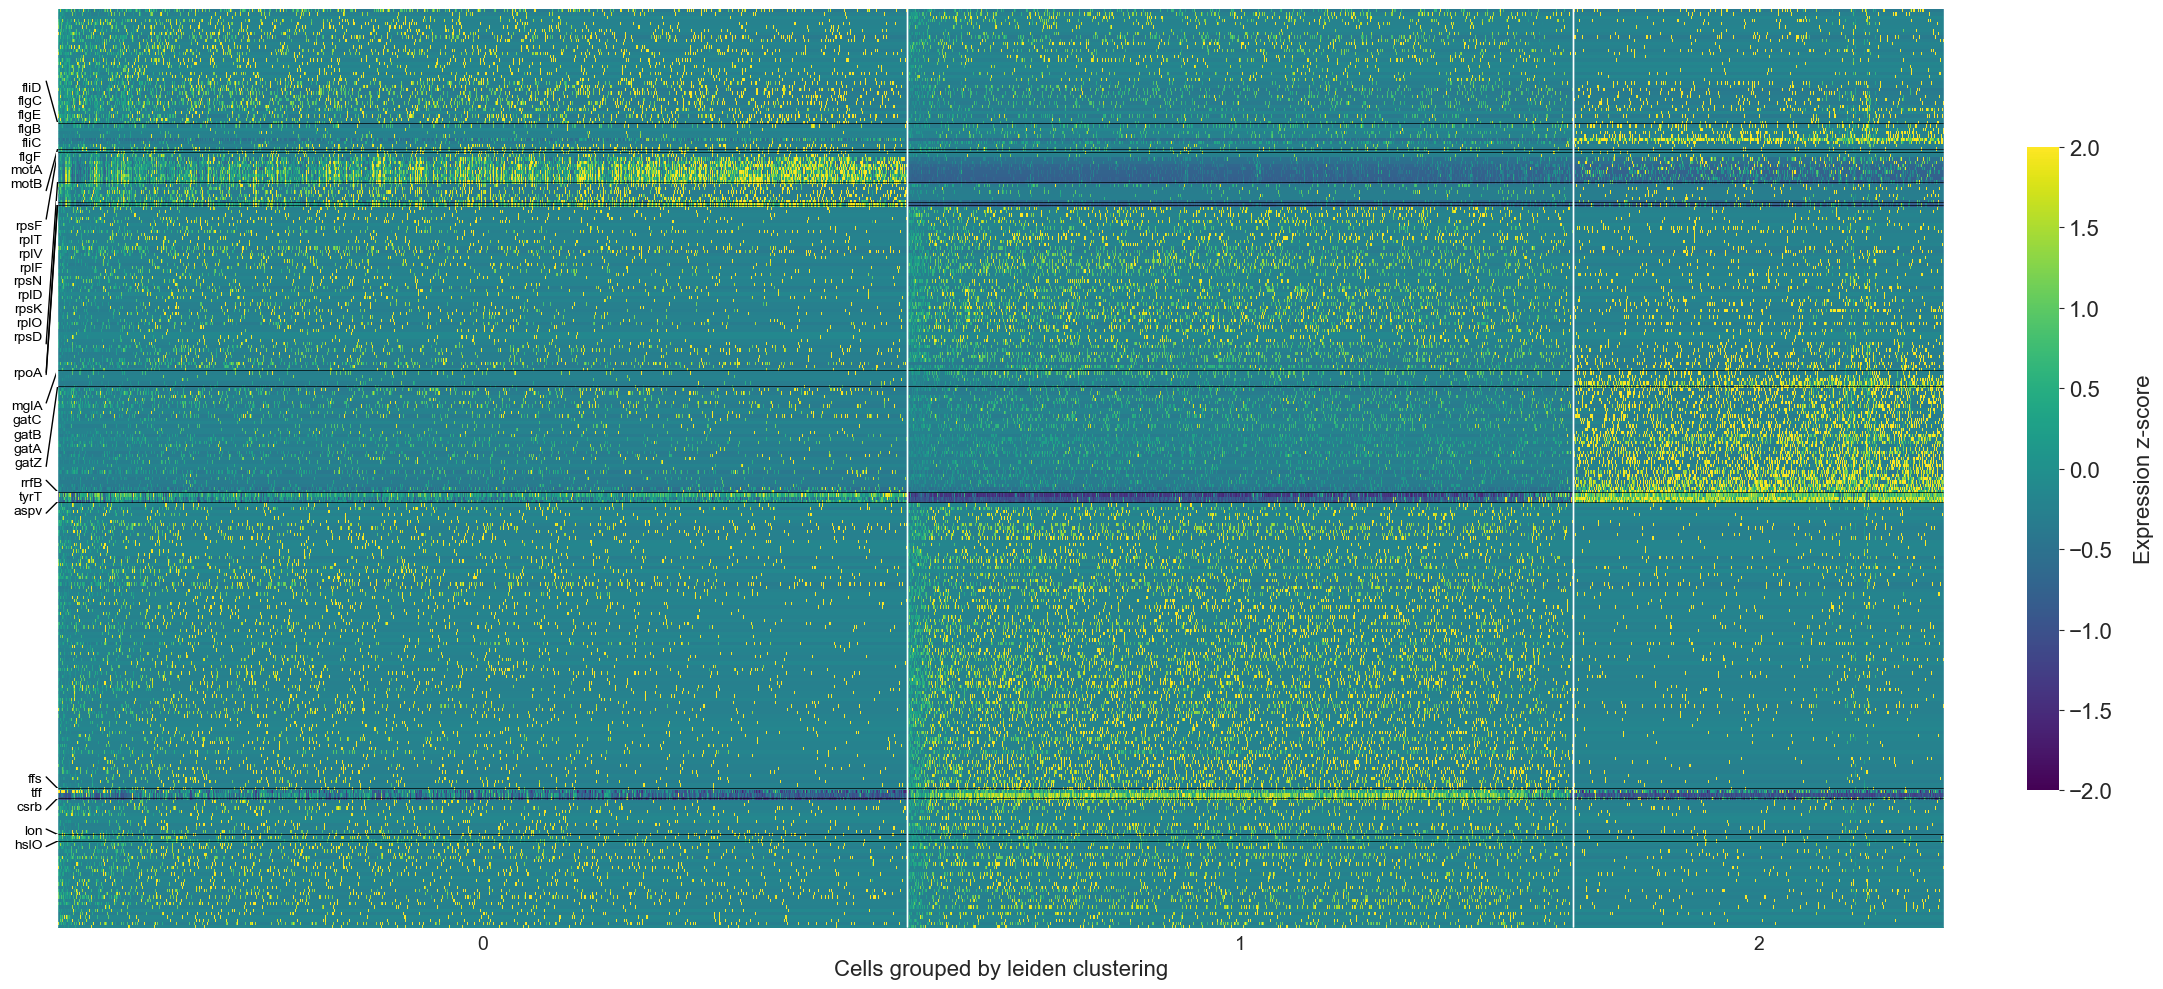

In [7]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import linkage, leaves_list
import scipy.sparse as sp
import os

# ---------------- CONFIG ----------------
groupby   = "leiden"
topN      = 100
p_cut     = 0.05
down_grp  = "3"            # for this cluster take the 100 lowest scores
use_raw   = False          # True -> use adata.raw
layer     = 'counts'           # e.g. "lognorm"
metric    = "correlation"
method    = "average"

# order cells inside each cluster: "umap" (fast) or "cluster" (hierarchical)
order_cells_within_cluster = "umap"
adata = sc.read_h5ad(os.path.join(os.path.dirname(os.getcwd()), 'data', 'scanpy_vapc.h5ad'))
# Curated groups to emphasize (edit to your genes)
gene_groups = {
    "Protease/Chaperones": ["clpA","clpB","clpX","clpP","lon","ftsH","dnaK","hslO","hslU","hslV"],
    "Ribosomal": ["rplA","rplC","rplD","rplE","rplF","rplJ","rplL","rplM","rplN","rplO","rplQ","rplR","rplS","rplT","rplU","rplV", "rpsA","rpsC","rpsD","rpsE","rpsF","rpsH","rpsI","rpsJ","rpsK","rpsL","rpsM","rpsN","rpsO"],
    "Carbohydrate utilization": ["gatA","gatB","gatC","gatZ", "mglA", "araG","araF"],
    "Motility": ["fliA","fliB","fliC","fliD","fliE","fliF","fliS","fliT","flgA","flgB","flgC","flgM","flgN","flgE","flgF","flgK","flgL","motA","motB"],
    'transcription': ['rpoA'],
    't/rRNA': ['tyrT','aspv','rrfB'],
    'sRNA': ['ffs','tff','csrb']
}
# ---------------------------------------

# ---------- 1) Rank & select markers (same rules as before) ----------
if "rank_genes_groups" not in adata.uns:
    sc.tl.rank_genes_groups(adata, groupby=groupby, method="wilcoxon", layer=layer, use_raw=use_raw)

df = sc.get.rank_genes_groups_df(adata, None).copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=["pvals_adj","scores"])
cats = ['0','1','2']

picked = []
for grp in cats:
    sub = df[(df["group"] == grp) & (df["pvals_adj"] < p_cut)]
    pick = (sub.nsmallest(topN, "scores") if grp == down_grp else sub.nlargest(topN, "scores"))
    pick["chosen_group"] = grp
    picked.append(pick)

sel = pd.concat(picked, ignore_index=False)
sel["abs_score"] = sel["scores"].abs()
idx = sel.groupby('names')['abs_score'].idxmax()
sel = sel.loc[idx].sort_index()
#sel = (sel.sort_values("abs_score", ascending=False)
#          .drop_duplicates(subset="names", keep="first")
#          .drop(columns="abs_score"))
selected_genes = sel["names"].tolist()
# ---------- 2) Build cell-level matrix (no averaging), z-score by gene ----------
A = adata.raw.to_adata() if use_raw else adata

# choose values
Xfull = A.layers[layer] if layer is not None else A.X
if sp.issparse(Xfull):
    Xfull = Xfull.toarray()  # for z-scoring/cluster; if too big, consider float32 cast: Xfull = Xfull.astype(np.float32)

# keep only selected genes present
sel_genes_present = [g for g in selected_genes if g in A.var_names]
gidx = A.var_names.get_indexer(sel_genes_present)
Xsel = Xfull[:, gidx]                # shape: n_cells × n_sel_genes

# z-score per gene across cells (for display and ordering)
mu = np.nanmean(Xsel, axis=0)
sd = np.nanstd(Xsel, axis=0)
sd[sd == 0] = 1.0
Xsel_z = (Xsel - mu) / sd           # n_cells × n_sel_genes

# ---------- 3) Order cells (no averaging), grouped by Leiden ----------
obs_grp = A.obs[groupby].astype(str).values
cells_order = []
cluster_boundaries = []
start = 0
for grp in cats:
    idx = np.where(obs_grp == grp)[0]
    if len(idx) == 0:
        continue
    if order_cells_within_cluster == "umap" and "X_umap" in A.obsm:
        sub = idx[np.argsort(A.obsm["X_umap"][idx, 0])]
    elif order_cells_within_cluster == "cluster":
        Zc = linkage(Xsel_z[idx, :], method=method, metric=metric)
        sub = idx[leaves_list(Zc)]
    else:
        sub = np.sort(idx)
    cells_order.extend(sub.tolist())
    end = start + len(sub)
    cluster_boundaries.append((grp, start, end))
    start = end

# reorder cell axis
Xz_cell_ordered = Xsel_z[cells_order, :]   # n_cells_ordered × n_genes

# ---------- 4) Order genes globally, then blockify curated groups ----------
def order_genes(matrix_cells_by_genes):
    # matrix: n_cells × n_genes (z-scored)
    if matrix_cells_by_genes.shape[1] <= 2:
        return list(range(matrix_cells_by_genes.shape[1]))
    Z = linkage(matrix_cells_by_genes.T, method=method, metric=metric)
    return leaves_list(Z).tolist()

base_gene_order_idx = order_genes(Xz_cell_ordered)
base_order_genes = [sel_genes_present[i] for i in base_gene_order_idx]

# map gene -> group
gene2grp = {g: lab for lab, genes in gene_groups.items() for g in genes}
present_in_data = set(sel_genes_present)

final_gene_order = []
group_index_ranges = {}       # label -> (start_row, end_row_exclusive)
highlight_rows = []           # rows of genes belonging to curated groups
placed = set()
placed_groups = set()

i = 0
while i < len(base_order_genes):
    g = base_order_genes[i]
    if g in placed:
        i += 1
        continue
    grp = gene2grp.get(g, None)
    if grp is not None and grp not in placed_groups:
        present = [x for x in gene_groups[grp] if x in present_in_data and x not in placed]
        if present:
            # indices for these genes in current Xz matrix
            sel_idx = [sel_genes_present.index(x) for x in present]
            # order within this group by clustering on cell-level data
            Zg = linkage(Xz_cell_ordered[:, sel_idx].T, method=method, metric=metric) if len(sel_idx) > 2 else None
            ord_local = (np.array(sel_idx)[leaves_list(Zg)].tolist() if Zg is not None else sel_idx)
            genes_local = [sel_genes_present[j] for j in ord_local]
            s = len(final_gene_order)
            final_gene_order.extend(genes_local)
            e = len(final_gene_order)
            group_index_ranges[grp] = (s, e)
            highlight_rows.extend(range(s, e))
            placed.update(genes_local)
            placed_groups.add(grp)
        i += 1
    else:
        final_gene_order.append(g)
        placed.add(g)
        i += 1

# row-reorder: genes × cells
gene_pos = [sel_genes_present.index(g) for g in final_gene_order]
H = Xz_cell_ordered[:, gene_pos].T   # genes × cells (z-scored per gene)

# ---------- 5) Plot (matplotlib/seaborn) ----------
fig_h = max(10, 0.012 * H.shape[0] + 4)        # adaptive height for many genes
fig_w = max(7, 0.004 * H.shape[1] + 2)        # adaptive width for many cells
fig, ax = plt.subplots(figsize=(fig_w, fig_h))
fontsize = 10
line_h = fontsize*1.2 # in points

hm = sns.heatmap(
    H,
    ax=ax,
    cmap="viridis",
    cbar=True,
    linewidths=0,
    linecolor=None,
    cbar_kws={
        'label': 'Expression level (a.u.)',
        'fraction': 0.05,  # makes it thinner
        'pad': 0.04,        # distance from the heatmap
        'shrink': 0.7,      # shrink size
    },
    xticklabels=False,     # many cells -> keep axis clean
    yticklabels=False,     # we’ll add group labels only
    vmin=-2, vmax=2        # clamp for contrast; remove if undesired
)
def multiline_string(list):
    return "\n".join(list)
# Horizontal group separators + group labels at midpoints + subtle row marks
n_cells = H.shape[1]
n_genes = H.shape[0]
row_h = fig_h * 72 / n_genes   # in points
top_border = 0
bottom_border = 0
def reorder_list(list1, list2):
    """
    Reorder elements in list1 according to their order in list2.
    Elements not in list2 are removed.
    """
    order_map = {x: i for i, x in enumerate(list2)}
    return sorted([x for x in list1 if x in order_map], key=lambda x: order_map[x])

for label, (s, e) in group_index_ranges.items():
    mid = (s + e - 1) / 2.0
    # separators
    ax.hlines([s - 0.5, e - 0.5], -0.5, n_cells - 0.5, linewidth=.5, color="black")
    # add tidy y-tick at midpoint
    ticks = ax.get_yticks().tolist()
    labs  = [t.get_text() for t in ax.get_yticklabels()]
    #ax.set_yticks(ticks + [s-0.5,e-0.5])
    gene_labels = reorder_list(gene_groups[label], final_gene_order)
    ylabel_str = multiline_string(gene_labels)
    n_lines = len(gene_labels)
    top_border = mid - (n_lines*line_h/2)/row_h
    if top_border < bottom_border:
        nudge = (bottom_border - top_border) + line_h/row_h
        mid = mid + nudge # nudge up if overlapping
        top_border = mid - (n_lines*line_h/2)/row_h
    bottom_border = mid + (n_lines*line_h/2)/row_h
    ax.text(-40, mid, ylabel_str, ha="right", va="center", fontsize=10, color="black")
    # add slanted lines
    ax.plot([-30, 0], [top_border+2, s-.5], color="black", linewidth=1, clip_on=False)
    ax.plot([-30, 0], [bottom_border-2, e-.5], color="black", linewidth=1, clip_on=False)
    

# subtle “hash” marks on the left for curated genes
if len(highlight_rows):
    y = np.array(highlight_rows, dtype=float)
    x = np.full_like(y, -0.6, dtype=float)
    ax.scatter(x, y, s=12, marker="|", color="white", clip_on=False, zorder=5)

# Vertical cluster separators + top labels (no averaging used for the plot)
for grp, s, e in cluster_boundaries:
    ax.vlines([s - 0.5, e - 0.5], -0.5, H.shape[0] - 0.5, linewidth=1, color="white")

# Add cluster labels centered over each block
centers = [ (s + e - 1)/2.0 for _, s, e in cluster_boundaries ]
labels  = [ grp for grp, _, _ in cluster_boundaries ]
ax.set_xticks(centers)
ax.set_xticklabels(labels, rotation=0, fontsize=fontsize+4)
ax.tick_params(axis="x", pad=5, length=0)

#ax.set_ylabel("Genes (z-scored per gene across cells)")
ax.set_xlabel(f"Cells grouped by {groupby} clustering", fontsize=fontsize+6)
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=fontsize+6)  # optional: smaller tick labels
cbar.ax.set_ylabel('Expression z-score', rotation=90, labelpad=15, fontsize=fontsize+6)

plt.tight_layout()
# Rasterize the heatmap QUADMESH only (text/lines stay vector)
for coll in ax.collections:
    coll.set_rasterized(True)        # QuadMesh is in collections
plt.savefig("heatmap_cells_by_genes_vapc.pdf", bbox_inches='tight', dpi=300)
plt.show()


In [21]:
#final_gene_order.index('motB')
final_gene_order[53:65]

['motB',
 'trmD',
 'cmk',
 'rpsR',
 'dusB',
 'rimM',
 'rpsS',
 'rpmD',
 'rpoA',
 'argR',
 'ytjC',
 'hisC']